<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №6: Синтез цифровых фильтров (КИХ и БИХ)

## Часть 1. Синтез КИХ-фильтров методом окон

### Задание 1.1. Проектирование ФНЧ с разными окнами
Спроектируйте КИХ-ФНЧ с частотой среза 200 Гц (частота дискретизации 1000 Гц), длина фильтра 51 отсчёт. Используйте окна:
- прямоугольное,
- Ханна,
- Хемминга,
- Блэкмана.

Постройте на одном графике АЧХ (в дБ) всех четырёх фильтров. Сравните:
- крутизну среза,
- уровень пульсаций в полосе пропускания и заграждения,
- ширину переходной полосы.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

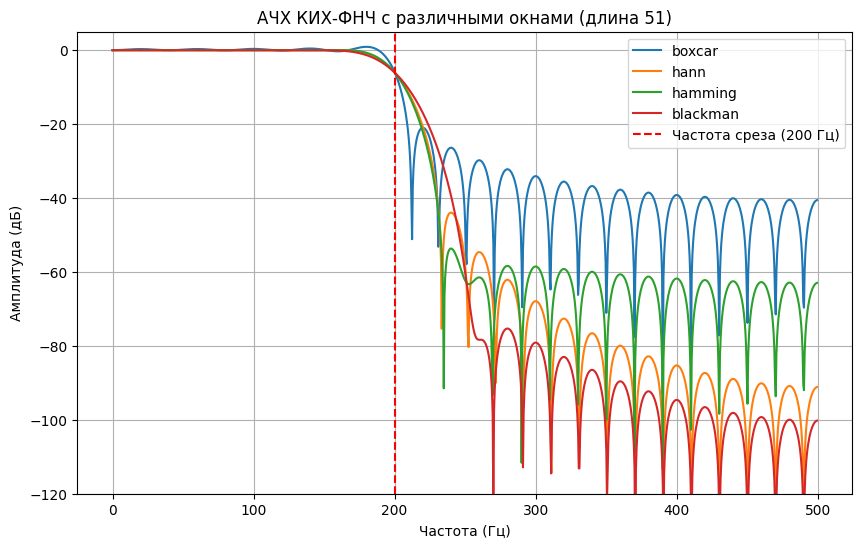

In [2]:
fs = 1000
fc = 200
numtaps = 51

windows = ['boxcar', 'hann', 'hamming', 'blackman']

plt.figure(figsize=(10, 6))

for win in windows:
    # Проектирование КИХ-фильтра
    b = signal.firwin(numtaps, fc, window=win, fs=fs)
    # Расчет АЧХ
    w, h = signal.freqz(b, 1, worN=1024, fs=fs)
    plt.plot(w, 20 * np.log10(np.abs(h) + 1e-12), label=win)

plt.title('АЧХ КИХ-ФНЧ с различными окнами (длина 51)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.ylim(-120, 5)
plt.axvline(fc, color='red', linestyle='--', label='Частота среза (200 Гц)')
plt.legend()
plt.show()

**Вопросы:** Какое окно обеспечивает наилучшее подавление в полосе заграждения? Какое – самую крутую переходную полосу? Как это связано с формой окна?

- Наилучшее подавление боковых лепестков в полосе заграждения (около −74 дБ) обеспечивает окно Блэкмана (blackman).

- Наиболее крутой срез имеет прямоугольное окно (boxcar).
- Это связано со свойством преобразования Фурье. Прямоугольное окно имеет резкие разрывы во временной области на границах интервала. В частотной области это порождает узкий главный лепесток, что дает крутой срез, но сопровождается высоким уровнем боковых лепестков (эффект Гиббса). Сглаживание оконной функции на краях (в окнах Ханна, Хемминга и Блэкмана) устраняет резкие перепады во временной области, снижая уровень боковых лепестков, но расширяет главный лепесток спектра окна , те увеличивая ширину переходной полосы.

### Задание 1.2. Влияние длины фильтра
Для окна Хемминга спроектируйте ФНЧ с fc=200 Гц, fs=1000 Гц, с длинами 21, 51, 101. Постройте АЧХ на одном графике.


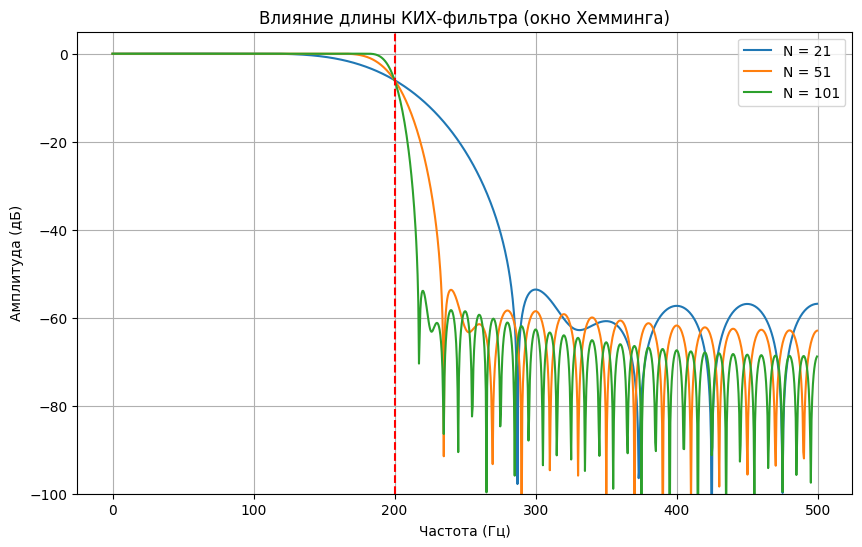

In [3]:
lengths = [21, 51, 101]

plt.figure(figsize=(10, 6))

for N in lengths:
    b = signal.firwin(N, fc, window='hamming', fs=fs)
    w, h = signal.freqz(b, 1, worN=1024, fs=fs)
    plt.plot(w, 20 * np.log10(np.abs(h) + 1e-12), label=f'N = {N}')

plt.title('Влияние длины КИХ-фильтра (окно Хемминга)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.ylim(-100, 5)
plt.axvline(fc, color='red', linestyle='--')
plt.legend()
plt.show()

**Вопрос:** Как увеличение длины влияет на крутизну среза и на уровень боковых лепестков?

Увеличение длины фильтра N сужает переходную полосу. При этом максимальный уровень боковых лепестков остается практически неизменным, поскольку он определяется исключительно типом выбранной оконной функции. При увеличении длины боковые лепестки лишь сжимаются по частоте, группируясь ближе к частоте среза.


### Задание 1.3. Синтез ФВЧ и полосового фильтра методом окон
Используя тот же оконный метод, спроектируйте:
- ФВЧ с fc=200 Гц (длина 51, окно Хемминга);
- полосовой фильтр с полосой пропускания 200–300 Гц (длина 51, окно Хемминга).

Постройте АЧХ обоих фильтров.


Подайте на спроектированные фильтры сигнал: сумма синусоид 100, 250 и 350 Гц (амплитуды 1, 0.8, 0.6). Постройте спектры до и после фильтрации (в логарифмическом масштабе).

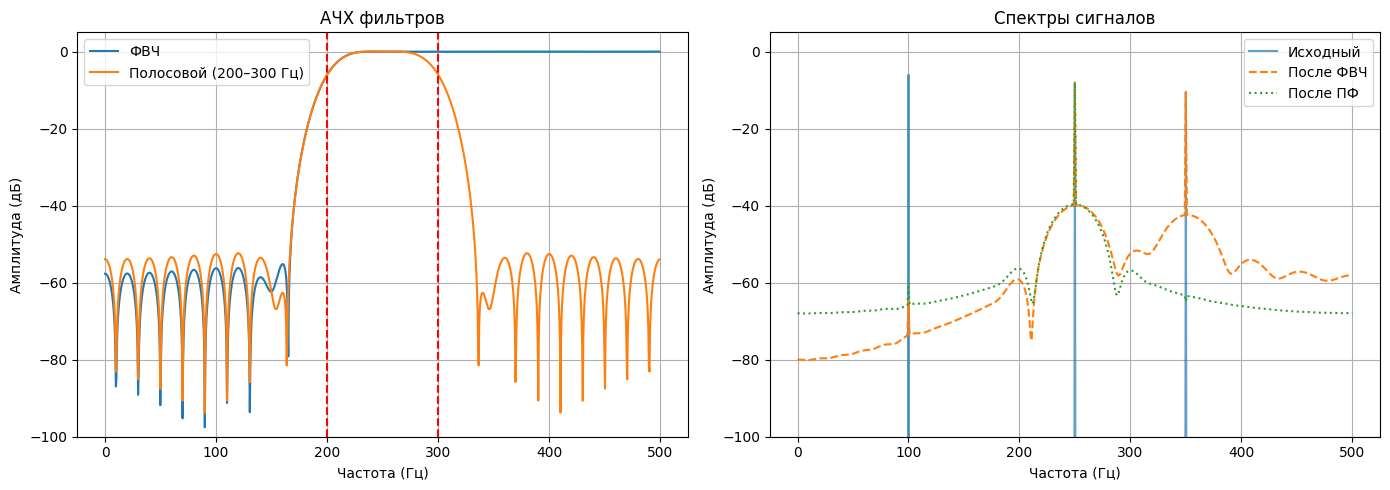

In [4]:
# Синтез ФВЧ
b_hpf = signal.firwin(51, fc, pass_zero='highpass', window='hamming', fs=fs)
# Синтез полосового фильтра
b_bpf = signal.firwin(51, [200, 300], pass_zero='bandpass', window='hamming', fs=fs)

# Расчет АЧХ
w_hpf, h_hpf = signal.freqz(b_hpf, 1, worN=1024, fs=fs)
w_bpf, h_bpf = signal.freqz(b_bpf, 1, worN=1024, fs=fs)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(w_hpf, 20 * np.log10(np.abs(h_hpf) + 1e-12), label='ФВЧ')
plt.plot(w_bpf, 20 * np.log10(np.abs(h_bpf) + 1e-12), label='Полосовой (200–300 Гц)')
plt.axvline(fc, color='red', linestyle='--')
plt.axvline(300, color='red', linestyle='--')
plt.title('АЧХ фильтров')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.ylim(-100, 5)
plt.legend()

# Генерация испытательного сигнала
t = np.arange(0, 1.0, 1/fs)
x = np.sin(2 * np.pi * 100 * t) + 0.8 * np.sin(2 * np.pi * 250 * t) + 0.6 * np.sin(2 * np.pi * 350 * t)

# Фильтрация
y_hpf = signal.lfilter(b_hpf, 1, x)
y_bpf = signal.lfilter(b_bpf, 1, x)

# Спектральный анализ
freqs = np.fft.rfftfreq(len(t), 1/fs)
X_fft = np.abs(np.fft.rfft(x)) / len(t)
Y_hpf_fft = np.abs(np.fft.rfft(y_hpf)) / len(t)
Y_bpf_fft = np.abs(np.fft.rfft(y_bpf)) / len(t)

plt.subplot(1, 2, 2)
plt.plot(freqs, 20 * np.log10(X_fft + 1e-12), label='Исходный', alpha=0.7)
plt.plot(freqs, 20 * np.log10(Y_hpf_fft + 1e-12), label='После ФВЧ', linestyle='--')
plt.plot(freqs, 20 * np.log10(Y_bpf_fft + 1e-12), label='После ПФ', linestyle=':')
plt.title('Спектры сигналов')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.ylim(-100, 5)
plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Объясните полученные результаты.

- Исходный многочастотный сигнал содержит три выраженных спектральных пика на частотах 100 Гц, 250 Гц и 350 Гц.
- После применения ФВЧ с частотой среза 200 Гц низкочастотная синусоида (100 Гц) оказалась подавленной (ее уровень упал ниже −50 дБ), в то время как компоненты на частотах 250 Гц и 350 Гц прошли без существенных изменений, так как они попадают в полоу пропускания ФВЧ.
- После полосового фильтра (200–300 Гц) пик на частоте 250 Гц сохранился, а пики на частотах 100 Гц и 350 Гц были подавлены, поскольку они находятся вне частотного интервала полосы пропускания.

## Часть 2. Равноволновой синтез КИХ-фильтров (Паркса–МакКлеллана)

### Задание 2.1. Проектирование оптимального ФНЧ
Используя `signal.remez`, спроектируйте ФНЧ с параметрами:
- частота дискретизации 1000 Гц,
- полоса пропускания 0–150 Гц,
- полоса заграждения 250–500 Гц,
- длина фильтра 21.

Постройте АЧХ (в линейном и логарифмическом масштабах) и сравните её с АЧХ КИХ-фильтра, полученного методом окон (окно Хемминга, та же длина, fc=200 Гц).

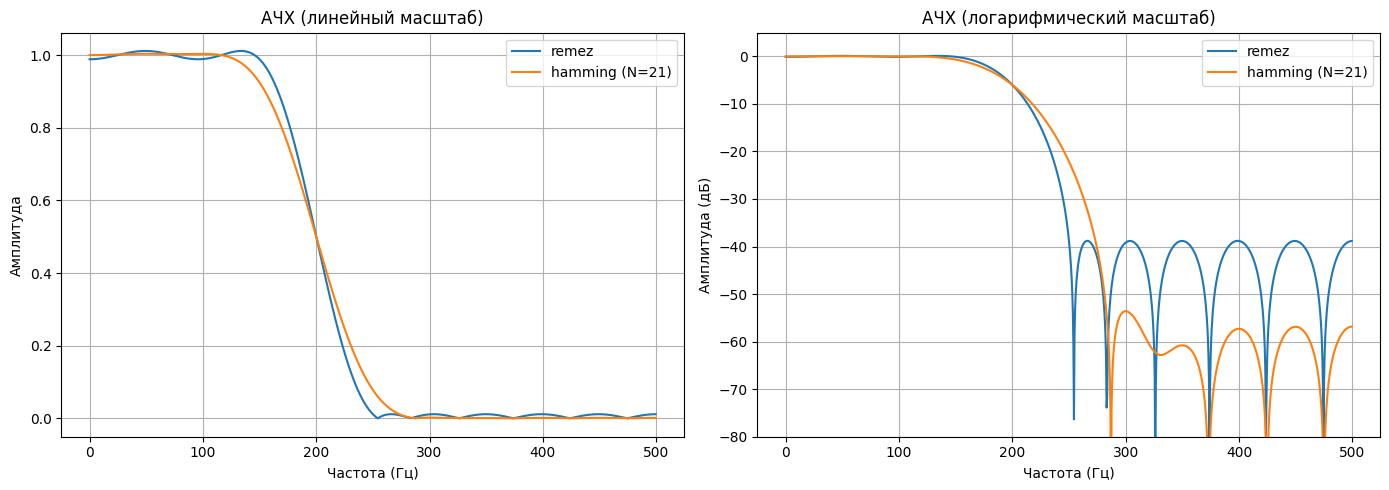

In [7]:
b_remez = signal.remez(21, [0, 150, 250, 500], [1, 0], fs=fs)
b_win_21 = signal.firwin(21, 200, window='hamming', fs=fs)

w_r, h_r = signal.freqz(b_remez, 1, worN=1024, fs=fs)
w_w, h_w = signal.freqz(b_win_21, 1, worN=1024, fs=fs)

plt.figure(figsize=(14, 5))

# Линейный масштаб
plt.subplot(1, 2, 1)
plt.plot(w_r, np.abs(h_r), label='remez')
plt.plot(w_w, np.abs(h_w), label='hamming (N=21)')
plt.title('АЧХ (линейный масштаб)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()

# Логарифмический масштаб
plt.subplot(1, 2, 2)
plt.plot(w_r, 20 * np.log10(np.abs(h_r) + 1e-12), label='remez')
plt.plot(w_w, 20 * np.log10(np.abs(h_w) + 1e-12), label='hamming (N=21)')
plt.title('АЧХ (логарифмический масштаб)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.ylim(-80, 5)
plt.legend()

plt.tight_layout()
plt.show()


**Вопросы:** Какой фильтр имеет более крутой срез? Каковы пульсации в полосе пропускания?


- Равноволновой фильтр (remez) при той же длине имеет более крутой срез, чем оконный фильтр Хемминга.
- У равноволнового фильтра в полосе пропускания присутствуют небольшие колебания одинаковой амплитуды около единицы, тогда как АЧХ оконного фильтра в этой полосе монотонна и более гладкая.

### Задание 2.2. Зависимость от ширины переходной полосы

Поменяйте верхнюю частоту полосы пропускания и нижнюю частоту полосы заграждения так, чтобы их среднее оставалось равным 200 Гц. Постройте АЧХ получившегося фильтра. Подберите ширину переходной области (разности нижней частоты полосы заграждения и верхней частоты полосы пропускания) так, чтобы уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга.


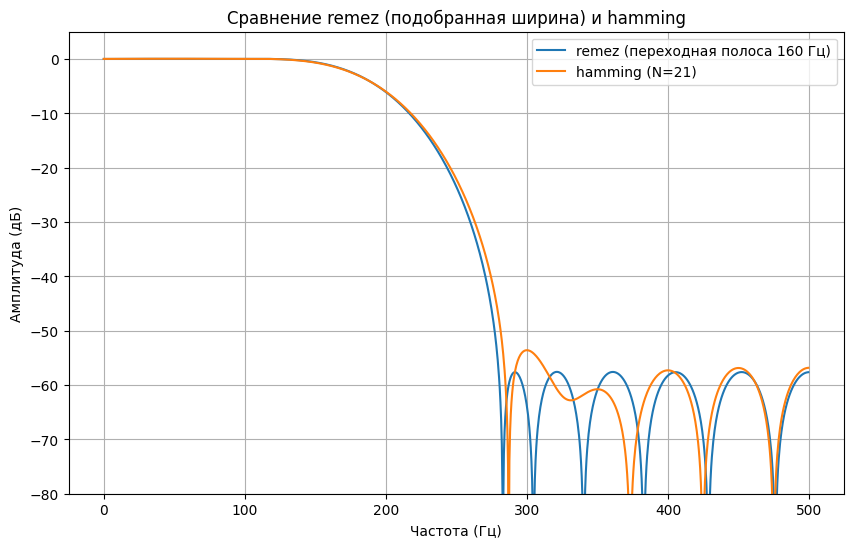

In [8]:
# Поиск ширины переходной зоны (df), при которой подавление совпадет
# У фильтра Хемминга N=21 подавление в полосе задерживания составляет около -53 дБ.
df = 160 # Расстояние между 120 Гц и 280 Гц (среднее = 200 Гц)
fp = 200 - df/2
f_stop = 200 + df/2

b_remez_match = signal.remez(21, [0, fp, f_stop, 500], [1, 0], fs=fs)
w_rm, h_rm = signal.freqz(b_remez_match, 1, worN=1024, fs=fs)

plt.figure(figsize=(10, 6))
plt.plot(w_rm, 20 * np.log10(np.abs(h_rm) + 1e-12), label=f'remez (переходная полоса {df} Гц)')
plt.plot(w_w, 20 * np.log10(np.abs(h_w) + 1e-12), label='hamming (N=21)')
plt.title('Сравнение remez (подобранная ширина) и hamming')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.ylim(-80, 5)
plt.legend()
plt.show()

**Вопрос:** При какой ширине переходной области уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга?

При ширине переходной области около  160 Гц (граница полосы пропускания 120 Гц, граница полосы заграждения 280 Гц) уровень подавления равноволнового фильтра в полосе заграждения совпадает с уровнем подавления оконного фильтра Хемминга той же длины (около −53 дБ).

### Задание 2.3. Управление весами
Для фильтра из задачи 2.1 измените весовые коэффициенты: задайте `weight=[1, 10]` (увеличить вес для полосы заграждения). Постройте новую АЧХ и сравните с предыдущей.


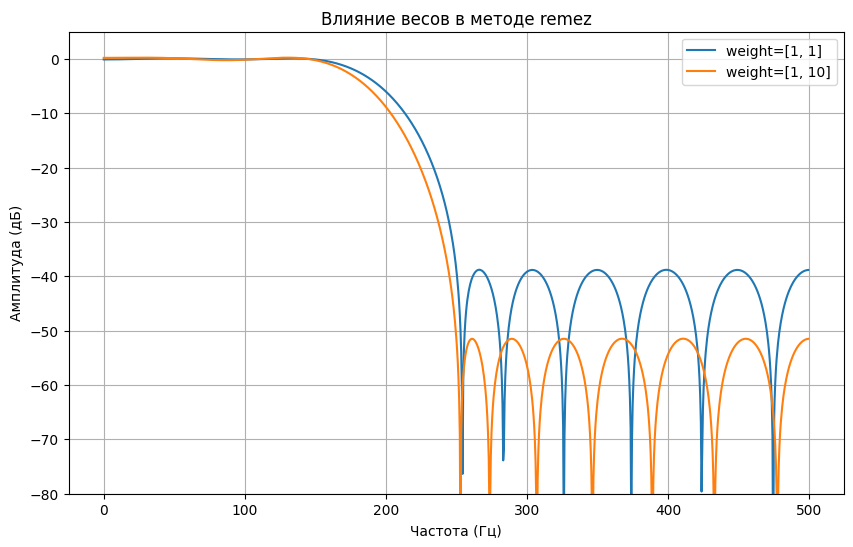

In [9]:
b_remez_weighted = signal.remez(21, [0, 150, 250, 500], [1, 0], weight=[1, 10], fs=fs)
w_rw, h_rw = signal.freqz(b_remez_weighted, 1, worN=1024, fs=fs)

plt.figure(figsize=(10, 6))
plt.plot(w_r, 20 * np.log10(np.abs(h_r) + 1e-12), label='weight=[1, 1]')
plt.plot(w_rw, 20 * np.log10(np.abs(h_rw) + 1e-12), label='weight=[1, 10]')
plt.title('Влияние весов в методе remez')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.ylim(-80, 5)
plt.legend()
plt.show()

**Вопрос:** Как изменилось подавление в полосе заграждения и пульсации в полосе пропускания?

При увеличении весового коэффициента полосы заграждения до 10 уровень подавления в ней увеличился (уровень боковых лепестков опустился примерно на 15 дБ). Однако при этом увеличилась неравномерность (амплитуда пульсаций) в полосе пропускания.


### Задание 2.4. Сравнение КИХ-фильтров на реальном сигнале
Сгенерируйте сигнал: смесь синусоид 50 Гц, 120 Гц, 220 Гц (амплитуды 1, 0.7, 0.3) + белый шум (дисперсия 0.1), fs=1000 Гц. Пропустите этот сигнал через:
- КИХ-ФНЧ спроектированный методом окон (окно Хемминга, длина 51, fc=150 Гц);
- КИХ-ФНЧ спроектированный методом `remez` (длина 51, полоса пропускания 0–100 Гц, полоса заграждения 200–500 Гц).

Постройте спектры исходного и отфильтрованных сигналов в линейном и логарифмическом масштабе.


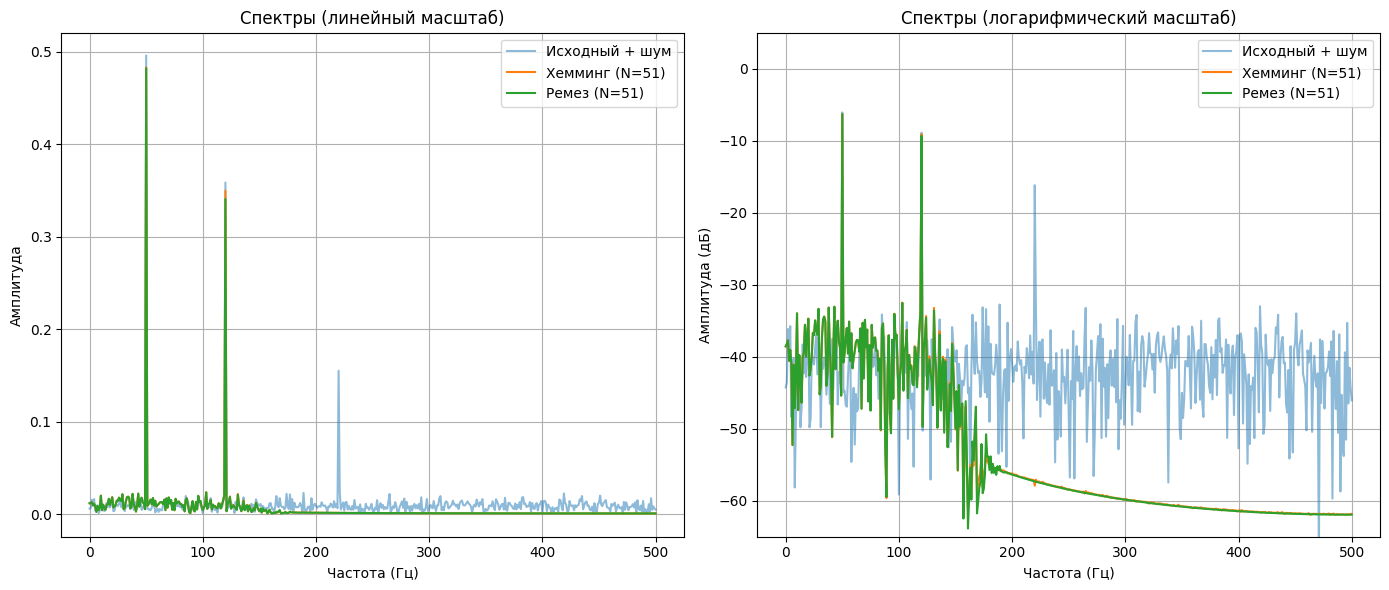

In [10]:
# Генерация сигнала с шумом
np.random.seed(42)
noise = np.random.normal(0, np.sqrt(0.1), len(t))
x_noise = (np.sin(2 * np.pi * 50 * t) +
           0.7 * np.sin(2 * np.pi * 120 * t) +
           0.3 * np.sin(2 * np.pi * 220 * t) + noise)

# Синтез фильтров длиной 51
b_win_51 = signal.firwin(51, 150, window='hamming', fs=fs)
b_remez_51 = signal.remez(51, [0, 100, 200, 500], [1, 0], fs=fs)

# Фильтрация
y_win = signal.lfilter(b_win_51, 1, x_noise)
y_remez = signal.lfilter(b_remez_51, 1, x_noise)

# Расчет спектров
freqs_4 = np.fft.rfftfreq(len(t), 1/fs)
X_n_fft = np.abs(np.fft.rfft(x_noise)) / len(t)
Y_win_fft = np.abs(np.fft.rfft(y_win)) / len(t)
Y_rem_fft = np.abs(np.fft.rfft(y_remez)) / len(t)

plt.figure(figsize=(14, 6))

# Спектры в линейном масштабе
plt.subplot(1, 2, 1)
plt.plot(freqs_4, X_n_fft, label='Исходный + шум', alpha=0.5)
plt.plot(freqs_4, Y_win_fft, label='Хемминг (N=51)')
plt.plot(freqs_4, Y_rem_fft, label='Ремез (N=51)')
plt.title('Спектры (линейный масштаб)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()

# Спектры в логарифмическом масштабе
plt.subplot(1, 2, 2)
plt.plot(freqs_4, 20 * np.log10(X_n_fft + 1e-12), label='Исходный + шум', alpha=0.5)
plt.plot(freqs_4, 20 * np.log10(Y_win_fft + 1e-12), label='Хемминг (N=51)')
plt.plot(freqs_4, 20 * np.log10(Y_rem_fft + 1e-12), label='Ремез (N=51)')
plt.title('Спектры (логарифмический масштаб)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.ylim(-65, 5)
plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр лучше подавил 220 Гц и шум? Какой лучше сохранил 120 Гц? На сколько отличаются амплитуды 120 Гц сигнала от исходных для каждого из фильтров?


- Фильтр, спроектированный методом Ремеза (remez), существенно лучше подавил частоту 220 Гц и шум в полосе заграждения, поскольку его полоса заграждения начинается с 200 Гц и уровень подавления в ней глубже.
- Оконный фильтр Хемминга лучше сохранил компоненту 120 Гц, так как эта частота располагается в его полосе пропускания (частота среза составляет 150 Гц). У фильтра Ремеза полоса пропускания спроектирована до 100 Гц, поэтому 120 Гц попадает в его переходную полосу и заметно ослабляется.
- Исходная амплитуда составляет 0.7. Оконный фильтр сохраняет амплитуду практически неизменной (близкой к 0.7). Фильтр Ремеза ослабляет данную составляющую более чем на половину из-за попадания в зону среза.

## Часть 3. Синтез БИХ-фильтров

### Задание 3.1. Баттерворт, Чебышев, эллиптический – сравнение АЧХ
Спроектируйте ФНЧ с частотой среза 200 Гц (fs=1000 Гц) следующих типов (порядок 4):
- Баттерворт (`butter`);
- Чебышев I с пульсациями 1 дБ (`cheby1`);
- Чебышев II с затуханием 40 дБ в полосе заграждения (`cheby2`);
- Эллиптический с пульсациями 1 дБ и затуханием 40 дБ (`ellip`).

Постройте АЧХ всех фильтров на одном графике (в дБ). Сравните:
- крутизну среза,
- пульсации в полосе пропускания и заграждения.

Постройте и сравните фазовые характеристики (ФЧХ) и групповые задержки.


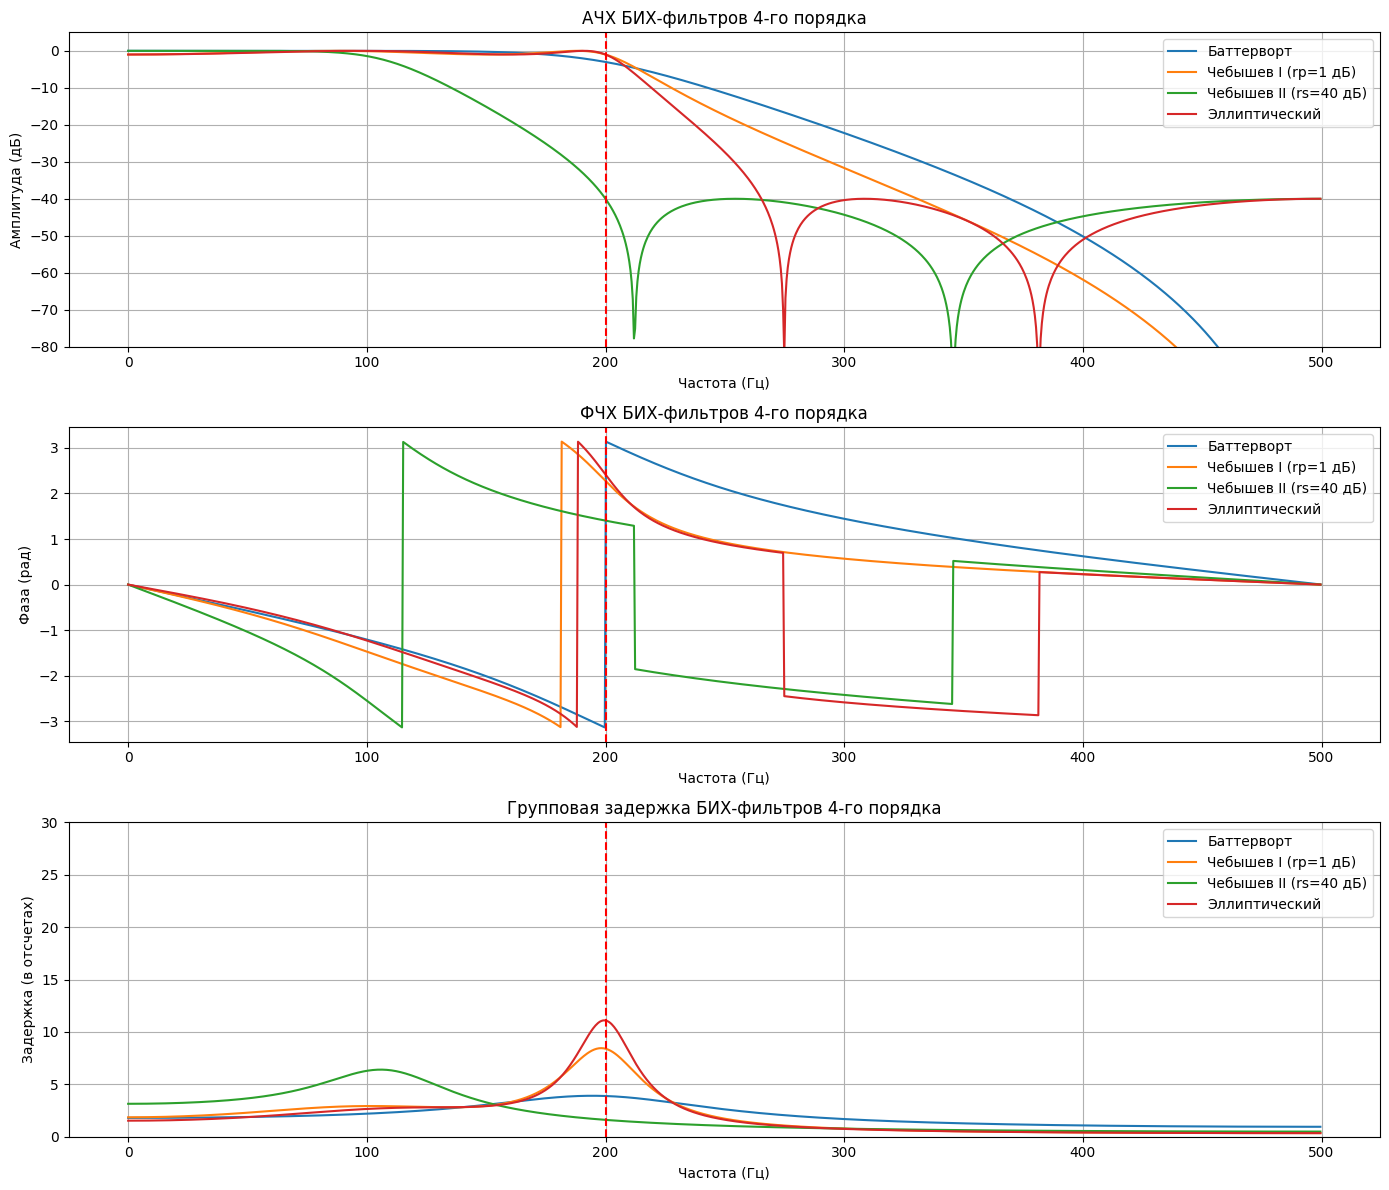

In [11]:
N = 4

# Проектирование БИХ-фильтров в формате SOS
sos_butter = signal.butter(N, fc, btype='low', output='sos', fs=fs)
sos_cheby1 = signal.cheby1(N, 1, fc, btype='low', output='sos', fs=fs)
sos_cheby2 = signal.cheby2(N, 40, fc, btype='low', output='sos', fs=fs)
sos_ellip = signal.ellip(N, 1, 40, fc, btype='low', output='sos', fs=fs)

filters = {
    'Баттерворт': sos_butter,
    'Чебышев I (rp=1 дБ)': sos_cheby1,
    'Чебышев II (rs=40 дБ)': sos_cheby2,
    'Эллиптический': sos_ellip
}

plt.figure(figsize=(14, 12))

# 1. АЧХ
plt.subplot(3, 1, 1)
for name, sos in filters.items():
    w, h = signal.sosfreqz(sos, worN=1024, fs=fs)
    plt.plot(w, 20 * np.log10(np.abs(h) + 1e-12), label=name)
plt.axvline(fc, color='red', linestyle='--')
plt.title('АЧХ БИХ-фильтров 4-го порядка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.ylim(-80, 5)
plt.legend()

# 2. ФЧХ
plt.subplot(3, 1, 2)
for name, sos in filters.items():
    w, h = signal.sosfreqz(sos, worN=1024, fs=fs)
    plt.plot(w, np.angle(h), label=name)
plt.axvline(fc, color='red', linestyle='--')
plt.title('ФЧХ БИХ-фильтров 4-го порядка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Фаза (рад)')
plt.grid(True)
plt.legend()

# 3. Групповая задержка (ГЗ)
plt.subplot(3, 1, 3)
for name, sos in filters.items():
    b, a = signal.sos2tf(sos)
    w_gd, gd = signal.group_delay((b, a), w=1024, fs=fs)
    plt.plot(w_gd, gd, label=name)
plt.axvline(fc, color='red', linestyle='--')
plt.title('Групповая задержка БИХ-фильтров 4-го порядка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (в отсчетах)')
plt.grid(True)
plt.ylim(0, 30)
plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр даёт самый крутой спад? Какой имеет наименьшие фазовые искажения в полосе пропускания?


- Самый крутой спад АЧХ при одном и том же порядке фильтра (N=4) обеспечивает эллиптический фильтр.

- Наименьшие фазовые искажения (наиболее близкую к линейной ФЧХ и максимально плоскую групповую задержку в полосе пропускания) обеспечивает фильтр Баттерворта. Эллиптический фильтр и фильтр Чебышева I имеют высокие пики групповой задержки у частоты среза, что вызывает фазовые искажения (дисперсию задержки составляющих сигнала).

### Задание 3.2. Влияние порядка на характеристики БИХ-фильтра
Для фильтра Баттерворта с fc=200 Гц, fs=1000 Гц возьмите порядки 2, 4, 6. Постройте АЧХ и групповую задержку.


/tmp/ipykernel_204258/3034999157.py:24: UserWarning: The filter's denominator is extremely small at frequencies [3.139], around which a singularity may be present
  w_gd, gd = signal.group_delay((b, a), w=1024, fs=fs)


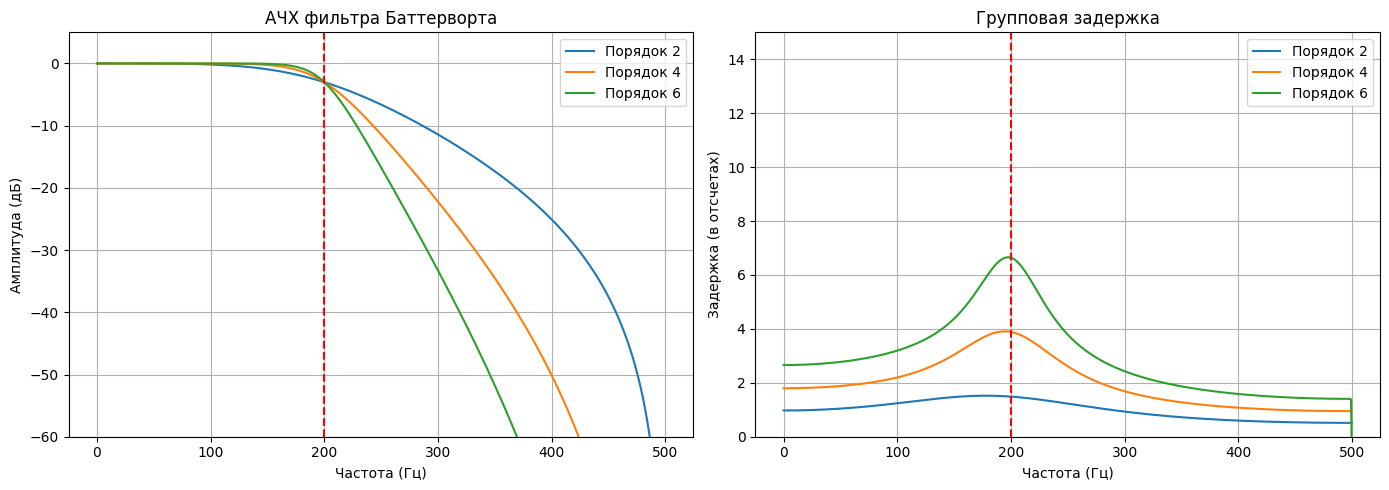

In [12]:
orders = [2, 4, 6]

plt.figure(figsize=(14, 5))

# АЧХ
plt.subplot(1, 2, 1)
for N_ord in orders:
    sos = signal.butter(N_ord, fc, btype='low', output='sos', fs=fs)
    w, h = signal.sosfreqz(sos, worN=1024, fs=fs)
    plt.plot(w, 20 * np.log10(np.abs(h) + 1e-12), label=f'Порядок {N_ord}')
plt.axvline(fc, color='red', linestyle='--')
plt.title('АЧХ фильтра Баттерворта')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.ylim(-60, 5)
plt.legend()

# Групповая задержка
plt.subplot(1, 2, 2)
for N_ord in orders:
    sos = signal.butter(N_ord, fc, btype='low', output='sos', fs=fs)
    b, a = signal.sos2tf(sos)
    w_gd, gd = signal.group_delay((b, a), w=1024, fs=fs)
    plt.plot(w_gd, gd, label=f'Порядок {N_ord}')
plt.axvline(fc, color='red', linestyle='--')
plt.title('Групповая задержка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (в отсчетах)')
plt.grid(True)
plt.ylim(0, 15)
plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Как увеличение порядка влияет на крутизну среза и на групповую задержку в полосе пропускания?

При увеличении порядка фильтра крутизна среза АЧХ значительно возрастает (переходная зона становится уже). При этом групповая задержка в полосе пропускания (особенно в области перехода, близкой к частоте среза) существенно возрастает по абсолютной величине, увеличивая фазовые искажения и общее время прохождения сигнала через систему.

### Задание 3.3. Преобразование типа БИХ-фильтра (ФНЧ → ФВЧ, полосовой)
Спроектируйте Баттерворта 4-го порядка:
- ФНЧ с fc=200 Гц;
- ФВЧ с fc=200 Гц (используйте `btype='high'`);
- полосовой с полосой 200–300 Гц.

Подайте на них сигнал: сумма синусоид 100, 250, 400 Гц. Постройте спектры после фильтрации.


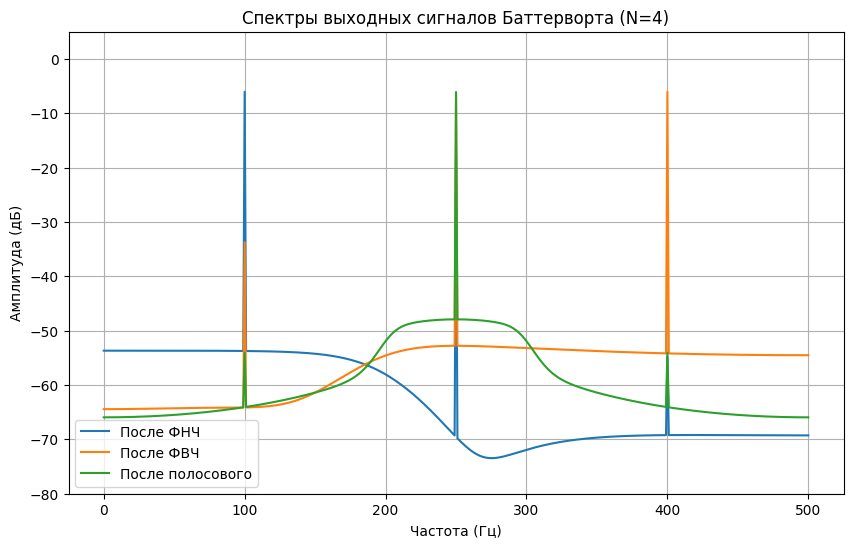

In [13]:
x_3 = np.sin(2 * np.pi * 100 * t) + np.sin(2 * np.pi * 250 * t) + np.sin(2 * np.pi * 400 * t)

# Синтез фильтров
sos_lpf = signal.butter(4, 200, btype='low', output='sos', fs=fs)
sos_hpf = signal.butter(4, 200, btype='high', output='sos', fs=fs)
sos_bpf = signal.butter(4, [200, 300], btype='bandpass', output='sos', fs=fs)

# Фильтрация
y_lpf = signal.sosfilt(sos_lpf, x_3)
y_hpf = signal.sosfilt(sos_hpf, x_3)
y_bpf = signal.sosfilt(sos_bpf, x_3)

# Расчет спектров
freqs_3 = np.fft.rfftfreq(len(t), 1/fs)
Y_lpf_fft = np.abs(np.fft.rfft(y_lpf)) / len(t)
Y_hpf_fft = np.abs(np.fft.rfft(y_hpf)) / len(t)
Y_bpf_fft = np.abs(np.fft.rfft(y_bpf)) / len(t)

plt.figure(figsize=(10, 6))
plt.plot(freqs_3, 20 * np.log10(Y_lpf_fft + 1e-12), label='После ФНЧ')
plt.plot(freqs_3, 20 * np.log10(Y_hpf_fft + 1e-12), label='После ФВЧ')
plt.plot(freqs_3, 20 * np.log10(Y_bpf_fft + 1e-12), label='После полосового')
plt.title('Спектры выходных сигналов Баттерворта (N=4)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.ylim(-80, 5)
plt.legend()
plt.show()

**Вопрос:** Какие составляющие подавлены, а какие пропущены в каждом случае?

После ФНЧ (срез 200 Гц): Составляющая 100 Гц пропущена. Составляющие 250 Гц и 400 Гц подавлены.

После ФВЧ (срез 200 Гц): Составляющие 250 Гц и 400 Гц пропущены. Составляющая 100 Гц подавлена.

После ПФ (полоса 200–300 Гц): Составляющая 250 Гц пропущена. Составляющие 100 Гц и 400 Гц подавлены.


### Задание 3.4. Применение БИХ-фильтра к зашумлённому сигналу
Сгенерируйте сигнал: синусоида 50 Гц + белый шум с дисперсией 0.2, fs=1000 Гц, длительность 1 с. Спроектируйте эллиптический ФНЧ с fc=100 Гц (порядок 6, пульсации 1 дБ, затухание 40 дБ). Примените фильтр с помощью `lfilter` и `filtfilt`. Постройте на одном графике исходный и отфильтрованные сигналы (временные области, первые 0.2 с), а также их спектры. Сравните задержку и подавление шума.


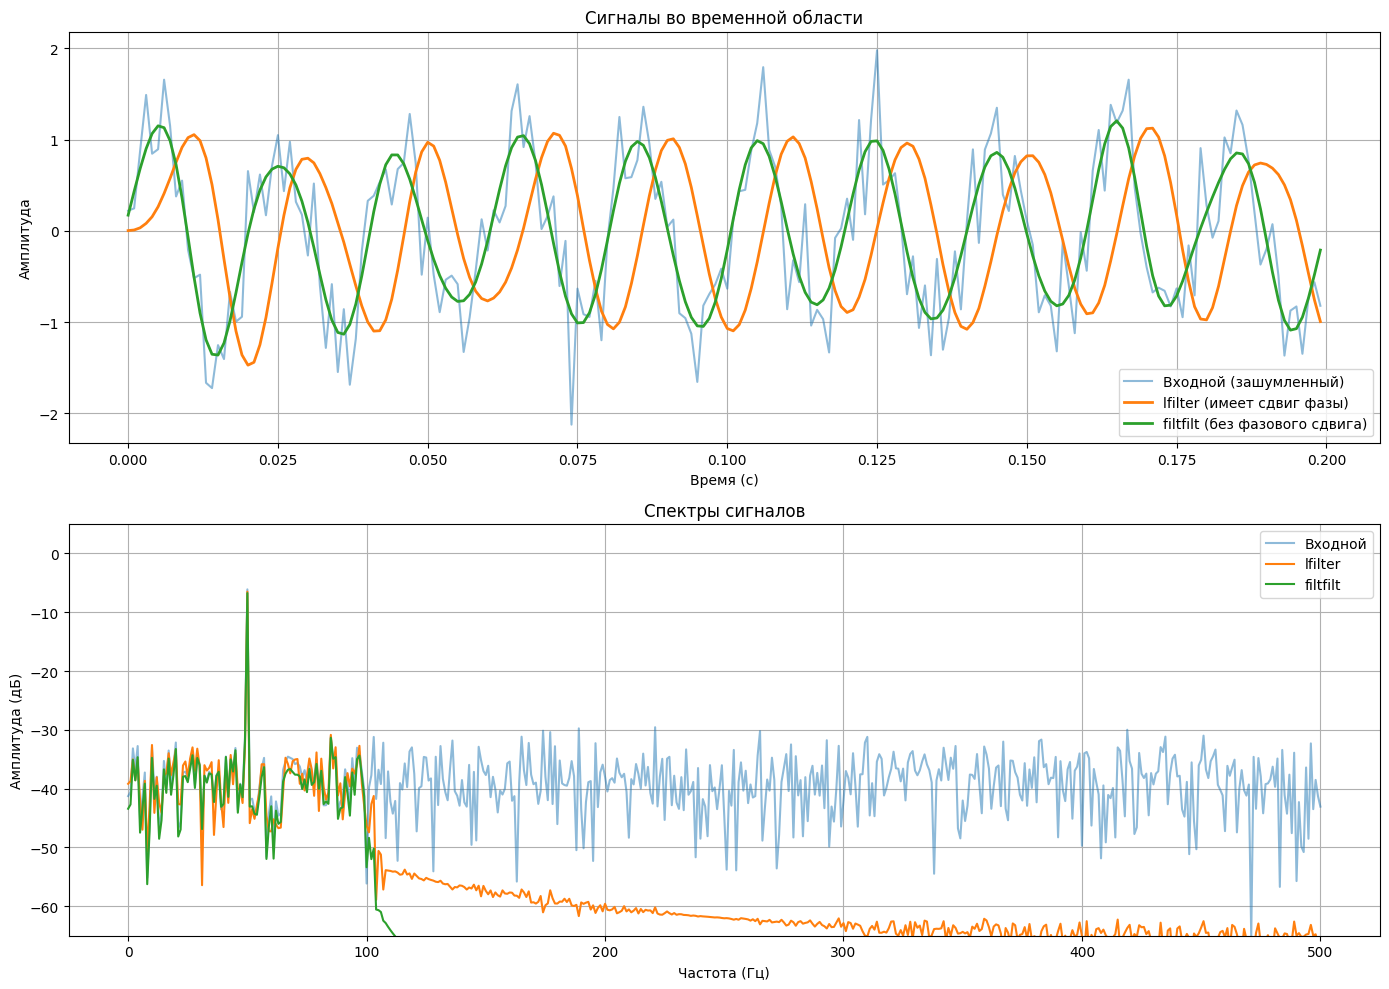

In [14]:
# Генерация зашумленного синуса 50 Гц
np.random.seed(42)
t_1s = np.arange(0, 1.0, 1/fs)
x_noisy = np.sin(2 * np.pi * 50 * t_1s) + np.random.normal(0, np.sqrt(0.2), len(t_1s))

# Синтез эллиптического фильтра (порядок 6, rp=1 дБ, rs=40 дБ, fc=100 Гц)
b_ell, a_ell = signal.ellip(6, 1, 40, 100, btype='low', fs=fs)

# Прямая и двусторонняя фильтрация
y_lfilt = signal.lfilter(b_ell, a_ell, x_noisy)
y_filtfilt = signal.filtfilt(b_ell, a_ell, x_noisy)

plt.figure(figsize=(14, 10))

# Временная область (первые 0.2 с)
plt.subplot(2, 1, 1)
plt.plot(t_1s[:200], x_noisy[:200], label='Входной (зашумленный)', alpha=0.5)
plt.plot(t_1s[:200], y_lfilt[:200], label='lfilter (имеет сдвиг фазы)', linewidth=2)
plt.plot(t_1s[:200], y_filtfilt[:200], label='filtfilt (без фазового сдвига)', linewidth=2)
plt.title('Сигналы во временной области')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()

# Частотная область (Спектры)
freqs_nse = np.fft.rfftfreq(len(t_1s), 1/fs)
X_ns_fft = np.abs(np.fft.rfft(x_noisy)) / len(t_1s)
Y_lf_fft = np.abs(np.fft.rfft(y_lfilt)) / len(t_1s)
Y_ff_fft = np.abs(np.fft.rfft(y_filtfilt)) / len(t_1s)

plt.subplot(2, 1, 2)
plt.plot(freqs_nse, 20 * np.log10(X_ns_fft + 1e-12), label='Входной', alpha=0.5)
plt.plot(freqs_nse, 20 * np.log10(Y_lf_fft + 1e-12), label='lfilter')
plt.plot(freqs_nse, 20 * np.log10(Y_ff_fft + 1e-12), label='filtfilt')
plt.title('Спектры сигналов')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.ylim(-65, 5)
plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Почему `filtfilt` даёт нулевой фазовый сдвиг?

- Фильтрация через lfilter (прямая фильтрация) вносит задержку (сдвиг по времени вправо). Метод filtfilt (двусторонняя фильтрация) полностью устраняет фазовый сдвиг, восстанавливая исходное временное положение гармоники. В спектральной области подавление ВЧ-помех у filtfilt выше (затухание в полосе заграждения удваивается в децибелах, достигая около −80 дБ вместо −40 дБ), так как сигнал проходит фильтр дважды.

При прохождении сигнала через фильтр в прямом направлении на каждой частотной компоненте накапливается фазовый сдвиг $ϕ(ω)$. При прохождении в обратном направлении вносится фазовый сдвиг − $ϕ(ω)$. Алгебраическая сумма этих сдвигов равна нулю, что обеспечивает строго нулевой фазовый сдвиг результирующего процесса на всех частотах.

## Часть 4. Сравнение КИХ и БИХ фильтров одинакового порядка

### Задание 4.1. Сравнение характеристик
Спроектируйте:
- КИХ-ФНЧ методом окон (окно Хемминга, длина 51, fc=200 Гц);
- БИХ-ФНЧ Баттерворта 4-го порядка (fc=200 Гц).

Постройте для них на одном графике:
- отдельно АЧХ (в дБ),
- отдельно групповую задержку.


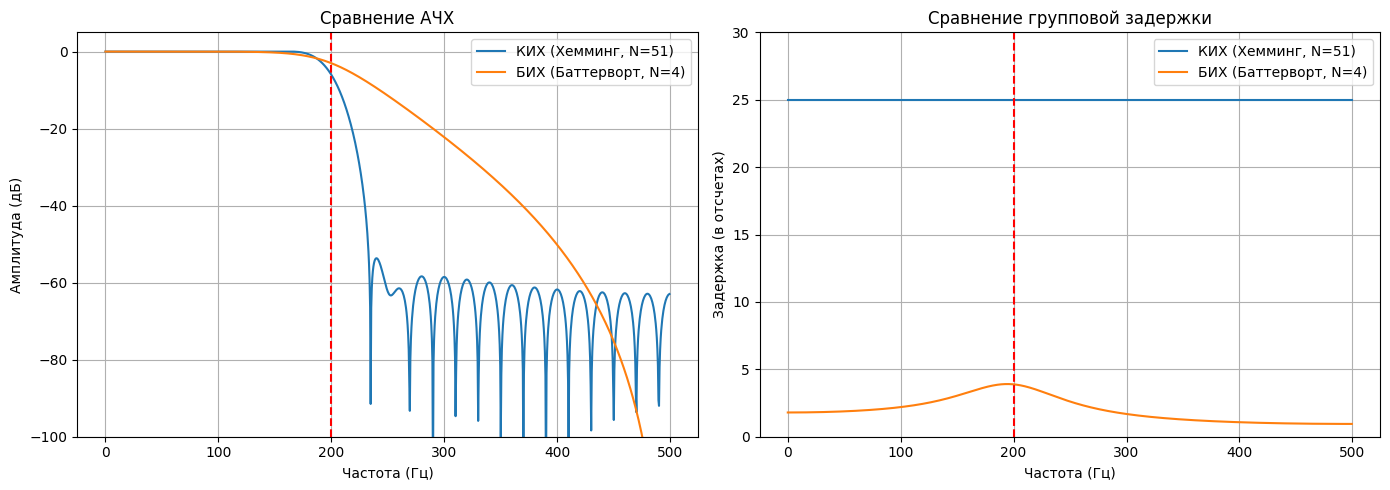

In [15]:
fs = 1000
fc = 200

# КИХ-ФНЧ (Хемминг, длина 51)
b_fir = signal.firwin(51, fc, window='hamming', fs=fs)

# БИХ-ФНЧ Баттерворта 4-го порядка
sos_iir = signal.butter(4, fc, btype='low', output='sos', fs=fs)
b_iir, a_iir = signal.sos2tf(sos_iir)

# Расчет частотных характеристик
w_fir, h_fir = signal.freqz(b_fir, 1, worN=1024, fs=fs)
w_iir, h_iir = signal.freqz(b_iir, a_iir, worN=1024, fs=fs)

w_fgd, gd_fir = signal.group_delay((b_fir, 1), w=1024, fs=fs)
w_igd, gd_iir = signal.group_delay((b_iir, a_iir), w=1024, fs=fs)

plt.figure(figsize=(14, 5))

# АЧХ
plt.subplot(1, 2, 1)
plt.plot(w_fir, 20 * np.log10(np.abs(h_fir) + 1e-12), label='КИХ (Хемминг, N=51)')
plt.plot(w_iir, 20 * np.log10(np.abs(h_iir) + 1e-12), label='БИХ (Баттерворт, N=4)')
plt.axvline(fc, color='red', linestyle='--')
plt.title('Сравнение АЧХ')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True)
plt.ylim(-100, 5)
plt.legend()

# Групповая задержка
plt.subplot(1, 2, 2)
plt.plot(w_fgd, gd_fir, label='КИХ (Хемминг, N=51)')
plt.plot(w_igd, gd_iir, label='БИХ (Баттерворт, N=4)')
plt.axvline(fc, color='red', linestyle='--')
plt.title('Сравнение групповой задержки')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (в отсчетах)')
plt.grid(True)
plt.ylim(0, 30)
plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр имеет более крутой срез? Какой имеет постоянную групповую задержку? Какой вносит меньшие фазовые искажения? Какой требует меньше вычислений? Попробуйте увеличить порядок фильтра Баттерворта. При каком порядке крутизна среза его АЧХ становится сравнимой с КИХ-фильтром? Растут или уменьшаются при этом фазовые искажения?


- Более крутой срез (более узкую переходную полосу) имеет БИХ-фильтр Баттерворта 4-го порядка.

- Постоянную групповую задержку ( $τ=(51−1)/2=25$ отсчетов) имеет КИХ-фильтр, так как он обладает линейной фазой.

- КИХ-фильтр не вносит фазовых искажений (форма сигнала не деформируется, происходит только сдвиг на фиксированное число отсчетов). БИХ-фильтр вносит заметные фазовые искажения из-за непостоянства групповой задержки по частоте.

- БИХ-фильтр 4-го порядка требует намного меньше вычислений (всего 9 коэффициентов/умножений на отсчет), тогда как КИХ-фильтр длиной 51 требует 51 умножение на каждый отсчет.

- Крутизна среза фильтра Баттерворта становится сравнимой с КИХ-фильтром (Хемминг, длина 51) при его порядке порядка 5–6. При этом фазовые искажения БИХ-фильтра значительно увеличиваются (растет пик групповой задержки вблизи границы полосы пропускания).

### Задание 4.2. Применение к реальному сигналу
Сгенерируйте сигнал: короткий прямоугольный импульс длительностью 10 мс, а также высокочастотная синусоидальная помеха 400 Гц. Частоту дискретизации возьмите fs=10000 Гц.

Примените оба фильтра (КИХ и БИХ из предыдущего пункта). Постройте исходный и отфильтрованные сигналы.


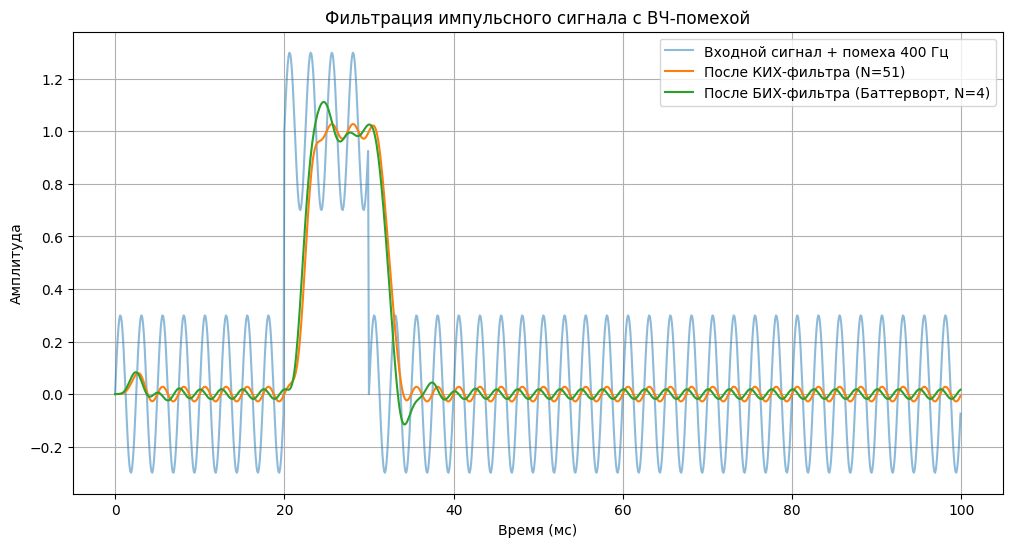

In [16]:
fs_p = 10000  # Частота дискретизации 10 кГц
fc_p = 200
t_p = np.arange(0, 0.1, 1/fs_p)  # 100 мс

# Генерация прямоугольного импульса длительностью 10 мс
pulse = np.zeros_like(t_p)
pulse[(t_p >= 0.02) & (t_p <= 0.03)] = 1.0

# Высокочастотная синусоидальная помеха 400 Гц
noise_sine = 0.3 * np.sin(2 * np.pi * 400 * t_p)
x_pulse_noisy = pulse + noise_sine

# Синтез фильтров на частоту дискретизации 10 кГц
b_fir_p = signal.firwin(51, fc_p, window='hamming', fs=fs_p)
sos_iir_p = signal.butter(4, fc_p, btype='low', output='sos', fs=fs_p)

# Фильтрация
y_fir_p = signal.lfilter(b_fir_p, 1, x_pulse_noisy)
y_iir_p = signal.sosfilt(sos_iir_p, x_pulse_noisy)

plt.figure(figsize=(12, 6))
plt.plot(t_p * 1000, x_pulse_noisy, label='Входной сигнал + помеха 400 Гц', alpha=0.5)
plt.plot(t_p * 1000, y_fir_p, label='После КИХ-фильтра (N=51)')
plt.plot(t_p * 1000, y_iir_p, label='После БИХ-фильтра (Баттерворт, N=4)')
plt.title('Фильтрация импульсного сигнала с ВЧ-помехой')
plt.xlabel('Время (мс)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()
plt.show()

**Вопросы:** Какой фильтр лучше сохранил форму импульсов? Какой лучше подавил помеху?


- Форму импульса лучше сохранил КИХ-фильтр. Форма выходного сигнала осталась строго симметричной (без фазовых искажений), импульс лишь задержался по времени на величину ГЗ (25 отсчетов, что при fs=10000 Гц соответствует задержке 2.5 мс). После БИХ-фильтра форма импульса сильно искажается, фронты становятся несимметричными, а на заднем фронте возникает затухающее колебание.

- При частоте дискретизации 10 кГц БИХ-фильтр Баттерворта 4-го порядка лучше подавил помеху 400 Гц, поскольку он обладает более крутым срезом АЧХ вблизи частоты 200 Гц. Для КИХ-фильтра Хемминга длиной 51 переходная полоса оказывается слишком широкой, поэтому ослабление на частоте 400 Гц у него меньше.